# FINAL
<b> Olympe Genty </b>
<br> 05/13/2025

In [50]:
# Set up directory and libraries
import os
os.chdir(r"C:\Users\olymp\OneDrive\Documents\SDSU\climath\dataClimStatBook\data\final")
os.getcwd() #get current working directory 

import numpy as np 
import pandas as pd

from datetime import timedelta

import math as m
import netCDF4 as nc

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm as cm1
from matplotlib.colors import LinearSegmentedColormap

from datetime import datetime
from PIL import Image

from scipy import optimize as opt
from scipy.ndimage import gaussian_filter
from sklearn.linear_model import LinearRegression

### Exercise 1

In [2]:
# Import Data
file = 'EarthTemperatureData.txt'
temp = pd.read_table(file, header = 0, delim_whitespace = True)
print(temp.head)
print(temp.shape)

<bound method NDFrame.head of      YEAR    JAN    FEB    MAR    APR    MAY    JUN    JUL    AUG    SEP  \
0    1850 -0.702 -0.284 -0.732 -0.570 -0.325 -0.213 -0.128 -0.233 -0.444   
1    1851 -0.303 -0.362 -0.485 -0.445 -0.302 -0.189 -0.215 -0.153 -0.108   
2    1852 -0.308 -0.477 -0.505 -0.559 -0.209 -0.038 -0.016 -0.195 -0.125   
3    1853 -0.177 -0.330 -0.318 -0.352 -0.268 -0.179 -0.059 -0.148 -0.409   
4    1854 -0.360 -0.280 -0.284 -0.349 -0.230 -0.215 -0.228 -0.163 -0.115   
..    ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
161  2011  0.313  0.327  0.425  0.480  0.384  0.489  0.510  0.488  0.454   
162  2012  0.306  0.302  0.358  0.575  0.574  0.557  0.510  0.536  0.553   
163  2013  0.450  0.486  0.401  0.439  0.520  0.487  0.514  0.533  0.535   
164  2014  0.523  0.313  0.561  0.657  0.599  0.618  0.541  0.666  0.589   
165  2015  0.688  0.660  0.681  0.656  0.696  0.730  0.696  0.732  0.784   

       OCT    NOV    DEC  ANNUAL  
0   -0.452 -0.190 -0.2

C:\Users\olymp\AppData\Local\Temp\ipykernel_33832\3523858647.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  temp = pd.read_table(file, header = 0, delim_whitespace = True)


In [3]:
# Select June data
jun = temp.iloc[:,[0,6]]
print(jun.shape)
print(jun.head)

(166, 2)
<bound method NDFrame.head of      YEAR    JUN
0    1850 -0.213
1    1851 -0.189
2    1852 -0.038
3    1853 -0.179
4    1854 -0.215
..    ...    ...
161  2011  0.489
162  2012  0.557
163  2013  0.487
164  2014  0.618
165  2015  0.730

[166 rows x 2 columns]>


In [4]:
# Prepare for plot
years = np.linspace(1850,2015,166)
junT = jun.iloc[:,1]
junT = junT.astype(float)
print(years.shape) 
print(junT.shape) 

(166,)
(166,)


In [5]:
# Making sure no weird values
print(np.min(junT))
print(np.max(junT)) 

-0.58
0.73


In [6]:
# Making sure right years selected
print(jun.iloc[51:151,0])

51     1901
52     1902
53     1903
54     1904
55     1905
       ... 
146    1996
147    1997
148    1998
149    1999
150    2000
Name: YEAR, Length: 100, dtype: int64


In [7]:
# Set up data for linear trend 1901-2000
periodT = jun.iloc[51:151,1]
print(periodT)
period = np.linspace(1901,2000,100)
print(period.shape)

51    -0.159
52    -0.449
53    -0.551
54    -0.526
55    -0.329
       ...  
146    0.170
147    0.402
148    0.592
149    0.273
150    0.275
Name: JUN, Length: 100, dtype: float64
(100,)


In [9]:
# Finding linear trend
lm = LinearRegression()
lm.fit(period.reshape(-1,1), periodT)
trend = lm.coef_
prediction = lm.predict(period.reshape(-1, 1))
print(f'The 1901-2000 June trend is {trend[0]*100:.2f} °C per century.')

The 1901-2000 June trend is 0.64 °C per century.


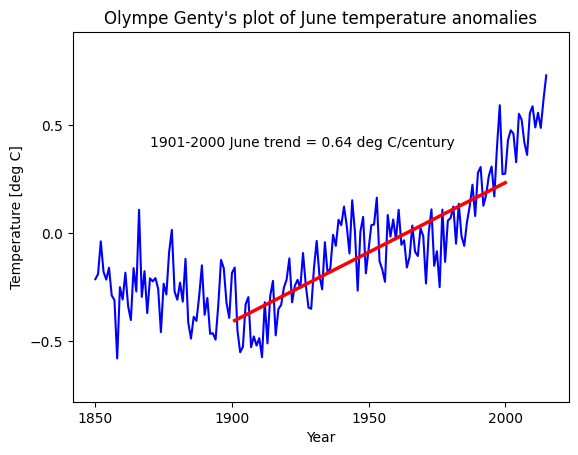

In [51]:
# Plot July temperature anomalies for 1850-2015 period with trend line
plt.plot(years, junT, "-", color = 'blue', markersize=5, 
         label="1850-2015 Data")
plt.plot(period, prediction, "-", color = 'red', linewidth = 2.5)

#I'm not saving my plot because I do not need to do it to display my plot in my pdf, 
#but if I did need to, here is the code I would use:
#plt.savefig('June_temp_anom.jpeg', format='jpeg', dpi=300)

plt.yticks(np.arange(-.5, 1 + 0.5, 0.5))
plt.xticks(np.arange(1850, 2050, 50))
plt.ylim(min(junT)-.2, max(junT)+.2)
plt.title("Olympe Genty's plot of June temperature anomalies")
plt.xlabel("Year")
plt.ylabel("Temperature [deg C]")
plt.text(1870,0.4, f'1901-2000 June trend = {trend[0]*100:.2f} deg C/century', 
         color = 'black', fontsize = 10)
plt.show()

<b> Figure 1 </b> Global average June mean global average surface air temperature anomalies from 1850-2015 with the 1901-2000 linear trend.

In [11]:
# Find the years with the highest and lowest temperature anomalies
jun.columns = jun.columns.astype(str)
jun.columns = jun.columns.str.strip()

max_y = jun.loc[jun['JUN'].idxmax()]
min_y = jun.loc[jun['JUN'].idxmin()]

print(f"{min_y.iloc[0]:.0f} was the year with the lowest temperature" +
      f" anomaly of {min_y.iloc[1]}°C.")
print(f"{max_y.iloc[0]:.0f} was the year with the highest temperature" +
      f" anomaly of {max_y.iloc[1]}°C.")

1858 was the year with the lowest temperature anomaly of -0.58°C.
2015 was the year with the highest temperature anomaly of 0.73°C.


### Exercise 2

In [13]:
# Import Darwin data
file1 = 'PSTANDdarwin.txt'
darwin = pd.read_table(file1, header = None, delim_whitespace = True)
print(darwin.head)
#print(darwin.shape)

<bound method NDFrame.head of       0    1    2    3    4    5    6    7    8    9    10   11   12
0   1951 -1.3 -1.6 -1.2 -0.4  0.4 -1.6 -0.1 -0.2  0.2  0.6  0.5  1.4
1   1952  0.0  0.2  0.0  0.4 -1.1 -0.4 -0.4 -0.7 -0.1 -0.8 -1.1  0.9
2   1953  0.2  0.4 -0.3 -0.9  1.5 -0.4  0.4 -0.3  0.9  0.0  0.5  0.6
3   1954 -1.6  0.4 -0.6 -2.0 -1.3 -0.6 -0.9 -1.4 -0.3 -0.1  0.2 -0.8
4   1955  1.5 -2.8 -1.5 -0.9 -1.9 -1.8 -1.6 -1.8 -1.2 -1.3 -1.2  0.2
..   ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...
60  2011 -1.4 -1.7 -1.8 -0.9  0.5  0.5 -0.2  0.2  0.3 -0.4 -0.3 -2.2
61  2012 -0.6  0.3 -1.8  0.7 -0.2  0.3 -0.6  0.6  0.0  0.0  0.4  0.3
62  2013 -0.8  0.3 -1.0 -0.2 -0.6 -1.6 -0.8 -0.3 -0.6 -0.1 -1.1  0.3
63  2014 -1.5 -0.8  0.7 -0.9  0.2 -0.4  0.4  1.0  0.8  0.8  0.9  0.1
64  2015 -0.2  0.9  0.5  0.6  1.5  0.3  1.4  1.3  1.5  2.8  0.5 -0.4

[65 rows x 13 columns]>


C:\Users\olymp\AppData\Local\Temp\ipykernel_33832\654568092.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  darwin = pd.read_table(file1, header = None, delim_whitespace = True)


In [14]:
# Import Tahiti data
file2 = 'PSTANDtahiti.txt'
tahiti = pd.read_table(file2, header = None, delim_whitespace = True)
print(tahiti.head)
#print(tahiti.shape)

<bound method NDFrame.head of       0    1    2    3    4    5    6    7    8    9    10   11   12
0   1951  1.3  0.0 -1.4 -0.9 -0.7 -1.3 -1.8 -0.5 -1.5 -1.0 -0.7  0.1
1   1952 -1.5 -0.8  0.8  0.0  0.2  0.8  0.4 -0.6 -0.5 -0.1 -1.1 -1.1
2   1953  0.7 -0.4 -0.6 -0.6 -1.3 -0.2  0.4 -2.3 -1.2  0.1  0.0 -0.1
3   1954 -0.5  0.0 -0.1 -0.9 -0.5 -0.4 -0.3  0.4  0.0  0.4  0.4  1.5
4   1955  0.6  0.3 -0.4 -1.1 -0.2  0.3  1.0  0.6  0.9  1.2  0.9  1.8
..   ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...
60  2011  2.4  2.9  2.3  2.2  1.1  0.9  1.4  0.9  2.0  0.8  1.5  1.9
61  2012  1.2  1.1 -0.7  0.3 -0.1 -0.4 -0.6  0.3  0.3  0.6  0.8 -0.7
62  2013 -0.9  0.0  1.4  0.2  0.7  0.4  0.4  0.1  0.0 -0.1  0.1  0.4
63  2014  0.8 -0.7 -0.9  0.4  1.1 -0.1  0.2 -0.2 -0.4 -0.2 -0.6 -0.8
64  2015 -1.5  1.3 -0.7  0.5  0.3 -0.6 -0.5 -1.1 -1.2 -0.1 -0.3 -1.3

[65 rows x 13 columns]>


C:\Users\olymp\AppData\Local\Temp\ipykernel_33832\960819823.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  tahiti = pd.read_table(file2, header = None, delim_whitespace = True)


In [15]:
# Extract December data
Ddec = darwin.iloc[:,12]
Tdec = tahiti.iloc[:,12]

In [54]:
# Create matrix A
A = np.vstack([Ddec,Tdec])
print(A.shape)

(2, 65)


In [55]:
# Display A 
columns = list(range(1951, 2016))
index = ['Darwin', 'Tahiti']
df = pd.DataFrame(A, index=index, columns=columns)
print(df)

        1951  1952  1953  1954  1955  1956  1957  1958  1959  1960  ...  2006  \
Darwin   1.4   0.9   0.6  -0.8   0.2  -1.6   0.3   0.8  -1.2  -0.2  ...   1.2   
Tahiti   0.1  -1.1  -0.1   1.5   1.8   0.1  -0.2  -0.2   0.3   1.1  ...   0.7   

        2007  2008  2009  2010  2011  2012  2013  2014  2015  
Darwin  -1.3  -0.8   0.5  -2.3  -2.2   0.3   0.3   0.1  -0.4  
Tahiti   1.5   1.6  -0.7   2.5   1.9  -0.7   0.4  -0.8  -1.3  

[2 rows x 65 columns]


In [56]:
#SVD analysis
A = np.asarray(A, dtype=np.float64)
svd = np.linalg.svd(np.asmatrix(A))
U = svd[0]
D = np.diag(svd[1])
V = svd[2]
V = V[0:2,:]

In [18]:
# EOF1, PC1, 1st singular value
print('\nThe EOF1 is the first column vector of U:')
print(U[:,0])
print('\nThe PC1 is the first row vector of V')
print(V[0,:])
print('\nThe corresponding singular value is:')
print(D[0,0])


The EOF1 is the first column vector of U:
[[-0.74784071]
 [ 0.66387821]]

The PC1 is the first row vector of V
[[-0.09790404 -0.14011062 -0.05142787  0.15915721  0.10437614  0.12609382
  -0.03565638 -0.07298935  0.10948403  0.08784445  0.16410891  0.02072319
  -0.15176871 -0.03481808  0.02575298 -0.04144638 -0.06963616  0.02072319
   0.04312297  0.22887146  0.03824937 -0.1559602   0.20471698  0.03657277
   0.23961316 -0.03306339 -0.11771083 -0.0066283  -0.08792255 -0.00579
   0.05218807 -0.25949805 -0.00838299  0.01097598  0.02483659 -0.17668339
  -0.05637957  0.13927232 -0.07139085 -0.02902808 -0.20060358 -0.05881637
   0.02986638 -0.14681701 -0.05386467  0.11283723 -0.11527403  0.164187
   0.15831891  0.11207702 -0.09531105 -0.13188382  0.13515892 -0.08532955
  -0.00914319 -0.04320107  0.19649018  0.1657855  -0.08373105  0.3374391
   0.29020273 -0.06879786  0.0041134  -0.06049297 -0.05630147]]

The corresponding singular value is:
10.015819578749046


In [19]:
# EOF2, PC2, 2nd singular value
print('\nThe EOF2 is the second column vector of U:')
print(U[:,1])
print('\nThe PC2 is the second row vector of V')
print(V[1,:])
print('\nThe corresponding singular value is:')
print(D[1,1])


The EOF2 is the second column vector of U:
[[0.66387821]
 [0.74784071]]

The PC2 is the second row vector of V
[[ 0.14172932 -0.03177426  0.0456631   0.08336237  0.20872245 -0.13935932
   0.00699962  0.05384772 -0.08077159  0.09736161  0.13376548  0.01173962
   0.07721658 -0.01292463 -0.10780584 -0.02347925 -0.02584925  0.01173962
  -0.01636924 -0.06073695 -0.23672092  0.1768378   0.17716898 -0.19687244
   0.02014503 -0.22272169 -0.05988312 -0.01055462  0.07258697 -0.03047887
   0.10436123 -0.0518089   0.19924244 -0.42896375  0.08206698  0.16509818
  -0.00474001  0.0516985   0.18394781  0.01755424 -0.10684162 -0.11491585
  -0.03747848  0.12761969 -0.06451274 -0.16046856  0.05029272 -0.03618309
   0.10328662 -0.31049289 -0.08799199  0.10888045 -0.01862885 -0.15713434
   0.04921811  0.18631781  0.03651427  0.093917   -0.02703425  0.04836428
  -0.00559383 -0.0457735   0.07032735 -0.07506736 -0.17468858]]

The corresponding singular value is:
7.085432814299158


In [20]:
# Verify that PC1 and PC2 are orthogonal
V[0,:] * V[1,:].T

matrix([[1.1969592e-16]])

1.1969592e-16 is very very close to 0, which means that the two vectors are orthogonal.

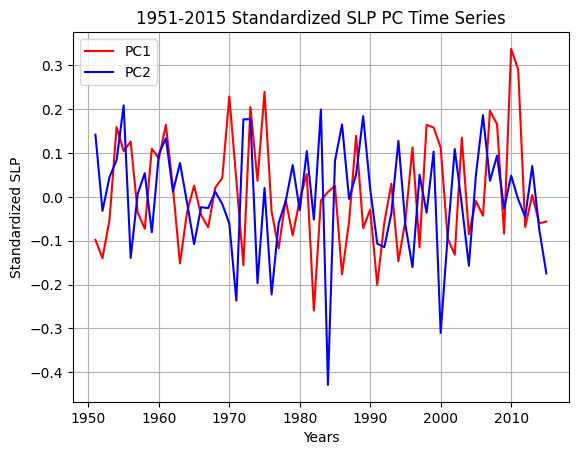

In [57]:
# Plot PCs
xtime = np.linspace(1951,2015,65)

PC1 = V[0,:].tolist()
PC2 = V[1,:].tolist()

plt.plot(xtime, PC1[0], "-", color = 'red', markersize=3, label='PC1')
plt.plot(xtime, PC2[0], "-", color = 'blue', markersize=3, label='PC2')

#I'm not saving my plot because I do not need to do it to display my plot in my pdf, 
#but if I did need to, here is the code I would use:
#plt.savefig('Darwin_Tahiti_PCs', format='jpeg', dpi=300)

plt.xticks(np.arange(1950, 2015, 10))
plt.grid()
plt.legend(loc='best')
plt.title('1951-2015 Standardized SLP PC Time Series')
plt.xlabel("Years")
plt.ylabel("Standardized SLP")
plt.show()

<b> Figure 2 </b> Darwin and Tahiti Principal Components (PCs) time series from 1951 to 2015.

### Exercise 3

Elisa Mitchell's calculation of Mount Mitchell's elevation uses the hypsometric equation, which relates the change in atmospheric pressure to the change in elevation under the assumption of hydrostatic equilibrium and ideal gas behavior. 
If one knows different parameters at two different elevations, such as the temperature or the atmospheric pressure, they can use the equation to determine the altitude of the top or bottom of the atmospheric layer, if the other is known. 

The hypsometric equation is the following: <br> 
$$z_2 = z_1 + \frac{2 R_1 R_2 T_1 T_2}{g_1R_2T_2+g_2R_1T_1} ln(\frac{p_1}{p_2})$$
where $z_1$ and $z_2$ are the two different elevations considered, $R_1$ and $R_2$ are the gas constant at each respective elevation, $T_1$ and $T_2$ the temperature (in Kelvin), and finally $p_1$ and $p_2$ the pressure. 
For our calculations, we consider that $R_1 = R_2 = 287.055 J.kg^{-1}.K^{-1}$ and $g_1 = g_2 = 9.80665 m.s^{-2}$.

From the North Carolina Climate Office NC ECONet's website (URL: https://econet.climate.ncsu.edu/), I obtained the following data: 
- Station MITC (elevation 6,200 ft): pressure <b>809.3 mb </b> and 48.4 F = <b>9.11°C</b>
- Station BURN (elevation 2,702ft): pressure <b>919.8 mb</b> and 55 F = <b>12.7°C</b>

With this data, the hypsometric equation becomes: <br> 
$$z = 2,702 \times 0.3048 + \frac{2(287.055)(273.15+9.11)(273.15+12.7)}{9.80665(2\times273.15+9.11+12.7)} ln(\frac{919.8}{809.3})$$

In [48]:
# Calculation of z
z = 2702 * 0.3048 + ((2*(287.055)*(273.15+9.11)*(273.15+12.7)) /
                     (9.80665*(2*273.15+9.11+12.7)))*np.log(919.8/809.3)
print(f'The elevation of Mount Mitchell is approximately {z:.2f}m,' +
      f' or {(z/0.3048):.2f} ft.')

The elevation of Mount Mitchell is approximately 1887.70m, or 6193.23 ft.


My estimation has a margin error of $|\frac{6193.23-6200}{6200}\times100|$ percents.

In [47]:
# Margin error
e = np.abs((((z/0.3048)-6200)/6200)*100)
print(f'The margin error is approximately {e:.1f}%,' +
      f' which is lower than 1%. My estimation seems very accurate.')

The margin error is approximately 0.1%, which is lower than 1%. My estimation seems very accurate.


### Exercise 4

<b> a)</b> <br>
The word "eigen" is a German word that means "own" or "self". An eigenvector (usually denoted <b>u</b>) is associated with a "mother" square matrix (denoted A) and refers to a non-zero vector that if multiplied by A, will stay in the same direction (though its magnitude may be scaled). We usually call this resulting vector <b>v</b>, and <b>v</b> is a scalar ($\lambda$) multipilication of <b>u</b>, where $\lambda$ is the associated eigenvalue. We can sum this up in the following formula: <br>
<br>
A<b>u</b> = <b>v</b> = $\lambda$ <b>u</b> <br> 
<br>
Most square matrices A (nxn) have n associated eigenvectors and eigenvalues, and they can be used to decompose (diagonalize) A.

<b> b)</b> <br>
Thanks to eigenvectors and eigenvalues, matrices can always be either diagonalized or written in Jordan form, but these methods are less efficient for large data sets and they only apply to square matrices. <br>
Singular Value Decomposition (SVD) is another way to decompose matrices to analyse them and it applies to any matrix, no matter its size. This charcateristic led this technique to revolutionize the field of data science. For instance, in the context of space-time decomposition, SVD is used to extract dominant spatial and temporal patterns from data matrices representing measurements across space and time.<br>
<br>
For an $n \times m$ space-time matrix $A$, with n spatial rows and m temporal columns, it can be decomposed into the product of three matrices, $U$, $D$, and $V^T$, such that $A = U\times D \times V^T$.<br> $U$ and $V^T$ are orthogonal matrices and $D$ is a diagonal matrix whose diagonal values are called A's "singular values". The column vectors of $U$ are called the Empirical Orthognal Functions (EOFs) of A for spatial patterns, and the row vectors of $V^T$ are its Principal Components (PCs) for temporal patterns.

For the dimensions of our matrices, we have two cases: m > n and n > m (<b>Figure 3</b>).

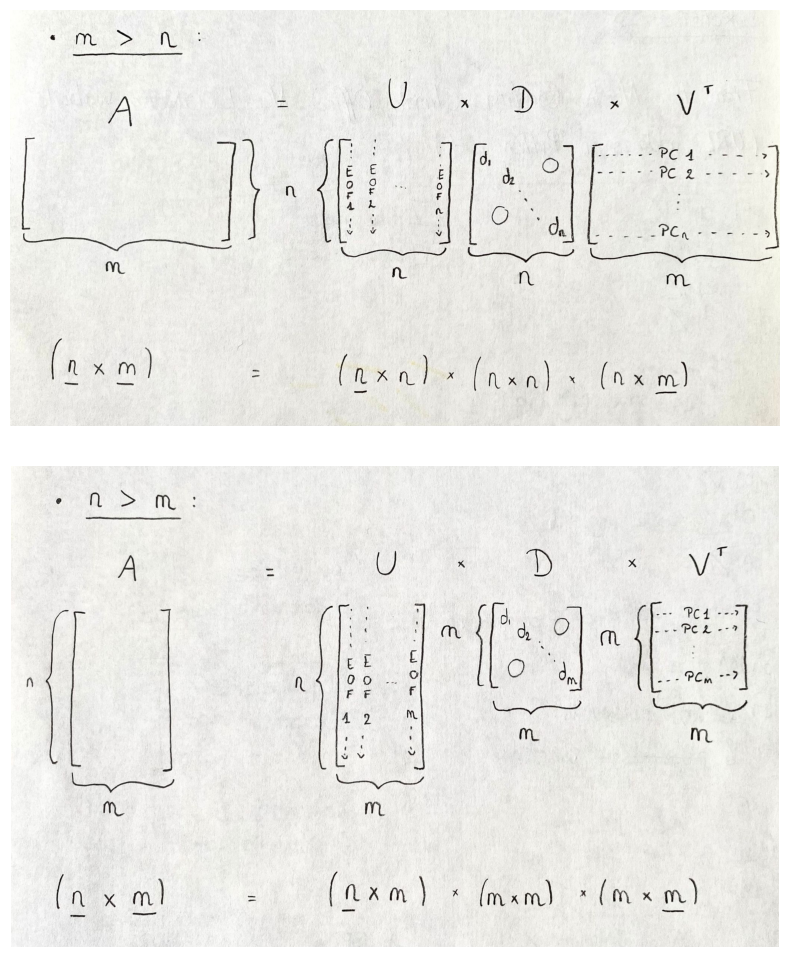

In [25]:
# SVD Diagrams (figure 3)
img1 = Image.open('SVD_diagram1.jpeg')
img2 = Image.open('SVD_diagram2.jpeg')

# Display the images
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 10))

axes[0].imshow(img1)
axes[0].axis('off') 

axes[1].imshow(img2)
axes[1].axis('off')  

plt.tight_layout()
plt.show()

<b> Figure 3 </b> Diagram of the Singular Value Decomposition (SVD) of an $n \times m$ matrix $A$, illustrating the dimensions of A, U, D, and V. 

<b> c)</b> <br>
Our Moon EBM is the result of balancing the incoming energy with the nergy lost by the moon's surface, as we can see in <b>Figure 4</b>. We obtain: $$E_{in} = E_{bb} + E_{cond} $$

- <b> Energy coming in </b> <br>
We know that the moon's surface gets solar radiation according to the formula: <br>
$$S_{in} = Scos({\beta})$$ where S is the solar constant ($S = 1,368 W.m^{-2}$) and $\beta$ is the solar zenith angle, which can be approximated by $\phi$, the latitude of the location of interest for our Energy Balance Model (EBM). <br>
However, some of these solar radiations are reflected back by the moon surface. The energy kept is $$E_{in} = S_{in}(1-{\alpha}) = (1-{\alpha})Scos({\phi})cos({\theta})$$ where $\theta$ is the longitude of the location of interest and $\alpha$ is the surface albedo, which is approximatively $0.12$ for the moon's surface.

- <b> Energy coming out </b> <br>

The moon's surface looses energy through thermal conduction and black body radiations. These losses can be calculated respectively using the following formulas: $$E_{cond}={\kappa} \frac{T - T_0}{h}$$ where $\kappa$ is the thermal conductivity of the regolith (${\kappa} = 7.4 * 10^{-4} W.m^{-1}.K^{-1}$), $T_0$ is the temperature of the moon's deep crust ($T_0 = 260 K$), and $h$ is the depth of the lunar crust that can be reached (we choose $h=0.4$m here); <br>
and $$E_{bb} = {\epsilon}{\sigma}T^4$$ where $\epsilon$ is the lunar surface emissivity (${\epsilon} = 0.98$) and $\sigma$ is the Stefan-Boltzmann constant (${\sigma} = 5.67 * 10^{-8} W.m^{-2}.K^{-4}$). <br>

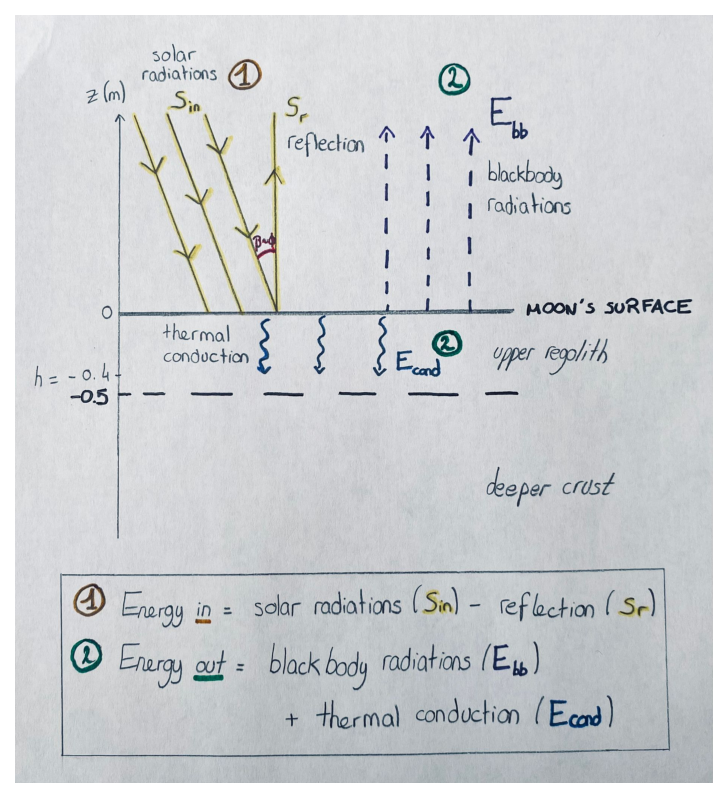

In [26]:
# EBM Diagram (figure 4)
img3 = Image.open('EBM_diagram.jpeg')

# Display the image
plt.figure(figsize=(6, 10), dpi=150)
plt.imshow(img3)
plt.axis('off')  # Hide axes
plt.show()

<b> Figure 4 </b> Schematic diagram of the energy fluxes involved in lunar Energy Balance Model (EBM) for the lunar surface temperature at a certain latitude $\phi$.

### Exercise 5

Our Moon EBM  $E_{in} = E_{bb} + E_{cond}$  (from Exercise 4) is equivalent to: $$(1-{\alpha})Scos({\phi})cos({\theta}) = {\kappa} \frac{T - T_0}{h} + {\epsilon}{\sigma}T^4$$ 

We can solve this equation for T using Python to get the temperature of the moon's surface at any location with latitude $\phi$ and longitude $\theta$. 

In [58]:
# Using our model to compute the surface temperature for different lon and lat
from scipy import optimize as opt

# Making a function to numerically solve an EBM
def ebm_maker(a, s, la, lo, e, si, ka, t0, he):
    """
    This function accepts a set of Energy Balance Model (EBM) parameters
    and returns a lambda function with those parameters as a function
    of t.
    """
    return lambda t: (1-a)*s*np.cos(la)*np.cos(lo) - e*si*(t**4) - ka*(t - t0)/he

In [28]:
# Using EBM to find moon surface temperature for lat 30° / lon 45°
lat = 30*np.pi/180
lon = 45*np.pi/180
sigma = 5.670367e-8
alpha = 0.12
S = 1368
ep = 0.98
k = 7.4e-4
h = 0.4
T0 = 260

fEBM = ebm_maker(alpha, S, lat, lon, ep, sigma, k, T0, h)

res = opt.root(fEBM, x0 = 400)
x0 = res['x'][0]
#print(x0)
print("The lunar surface temperature at lunar latitude 30° North and " + 
      f"at 3:00 pm lunar local time is {x0:.2f} K, or {(x0-273.15):.2f}°C.")

The lunar surface temperature at lunar latitude 30° North and at 3:00 pm lunar local time is 339.36 K, or 66.21°C.


### Exercise 6

In [29]:
# Import Data
datamat = nc.Dataset("air.mon.mean.nc")

In [30]:
# Preparing data for plotting 
Lon = datamat.variables['lon'][:]
Lat = datamat.variables['lat'][:]
Time = datamat.variables['time']
precnc = datamat.variables['air']

print(datamat)

<class 'netCDF4.Dataset'>
root group (NETCDF4_CLASSIC data model, file format HDF5):
    description: Data from NCEP initialized reanalysis (4x/day).  These are the 0.9950 sigma level values
    platform: Model
    Conventions: COARDS
    NCO: 20121012
    history: Thu May  4 20:11:16 2000: ncrcat -d time,0,623 /Datasets/ncep.reanalysis.derived/surface/air.mon.mean.nc air.mon.mean.nc
Thu May  4 18:11:50 2000: ncrcat -d time,0,622 /Datasets/ncep.reanalysis.derived/surface/air.mon.mean.nc ./surface/air.mon.mean.nc
Mon Jul  5 23:47:18 1999: ncrcat ./air.mon.mean.nc /Datasets/ncep.reanalysis.derived/surface/air.mon.mean.nc /dm/dmwork/nmc.rean.ingest/combinedMMs/surface/air.mon.mean.nc
/home/hoop/crdc/cpreanjuke2farm/cpreanjuke2farm Mon Oct 23 21:04:20 1995 from air.sfc.gauss.85.nc
created 95/03/13 by Hoop (netCDF2.3)
Converted to chunked, deflated non-packed NetCDF4 2014/09
    title: monthly mean air.sig995 from the NCEP Reanalysis
    References: http://www.esrl.noaa.gov/psd/data/gridded

In [31]:
# Find base year
print(Time.units)

hours since 1800-01-01 00:00:0.0


In [32]:
# Julian Date (days since 1800-01-01)
jd = Time[0]/24 

# Convert to calendar date 
base_date = datetime(1800, 1, 1)
calendar_date = base_date + timedelta(days=jd)
print(calendar_date.strftime('%Y-%m-%d'))

1948-01-01


In [33]:
# January data between 1961 and 2010
start_year = 1961
end_year = 2010
base_year = 1948

# Indices for Januarys between 1961 and 2010
jan_indices = 12 * np.arange(start_year - base_year, end_year - base_year + 1)

X = precnc[jan_indices]
print(X.shape)

(50, 73, 144)


In [34]:
# Janurary flat (2D) data matrix
X = X.reshape(50, -1).T
print(X.shape)

(10512, 50)


In [35]:
# Compute January climatology 
Janclim = np.mean(X, axis=1)

# Compute January standard deviation 
Jansd = np.std(X, axis=1)

In [36]:
print(X.shape[0])
print(Janclim.shape) 
print(Jansd.shape) 

10512
(10512,)
(10512,)


In [37]:
# Creating anomaly matrix Y
Y = np.zeros_like(X) 
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Y[i,j] = (X[i,j] - Janclim[i]) / Jansd[i]
print(Y.shape) 

(10512, 50)


In [38]:
# SVD analysis of anomaly matrix Y
svd = np.linalg.svd(np.asmatrix(Y))
U = svd[0]
D = np.diag(svd[1])
V = svd[2]
U = U[:,0:(X.shape[1])]

In [39]:
print(U.shape)

(10512, 50)


In [40]:
# Compute error of calculations
svd_error = (U*D*V) - Y
# Error maximum = almost zero to verify the SVD
print(svd_error.max())

2.3841858e-06


2.3841858e-06, almost zero => correct

In [49]:
# EOFs, PCs, singular values for Y
print('\nThe nth EOF correspond to the nth column of the matrix U of dimension:')
print(U.shape)
print('\nThe nth PC correspond to the nth row of the matrix V of dimension:')
print(V.shape)
print('\nThe associated singular value correspond to nth diagonal value of the' +
      ' matrix D of dimension:')
print(D.shape)


The nth EOF correspond to the nth column of the matrix U of dimension:
(10512, 50)

The nth PC correspond to the nth row of the matrix V of dimension:
(50, 50)

The associated singular value correspond to nth diagonal value of the matrix D of dimension:
(50, 50)


In [42]:
# Verify PC1 and PC2 orthogonal 
V[0,:] * V[1,:].T

matrix([[-2.4447218e-09]], dtype=float32)

-2.4447218e-09 is very close to 0, which means that the two vectors are orthogonal.